# Berry curvature and Chern numbers (Wilson-loop / FHS method)

Not an upstream Elk capability: `get_berry_curvature()` (mesh mode, task 9000) and
`get_berry_curvature_path()` (arbitrary-point mode, task 9001) implement the
Fukui-Hatsugai-Suzuki (FHS) Wilson-loop method (cond-mat/0503172) on top of Elk's
own wavefunction/overlap export machinery (`genwfsvp`/`genolpq`). All Wilson-loop
arithmetic (link variables, plaquette flux, Chern number) is done in Python
(`parsers/berry.py`), independently unit-tested against synthetic overlap matrices.
See `patches/0002-berry-curvature-wilson-loop.patch`, `docs/design.md` #13, and
`docs/physics.tex` Part II for the full physics writeup.

Two modes, two different guarantees:

- **Mesh mode** (`get_berry_curvature()`) evaluates the Wilson loop over a full
  periodic k-mesh -- the only way to get a genuine (topologically quantized) Chern
  number, but every corner has to be an actual mesh point.
- **Path mode** (`get_berry_curvature_path()`) evaluates one small Wilson loop per
  requested point via fresh on-the-fly diagonalisation -- works at *any* k-point
  (no `ngridk`/`reducek` alignment needed), at the cost of no Chern number (that
  needs a closed cover of the zone).

In [1]:
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np

from elkpy.structure import Structure

## Mesh mode: bulk Si is a trivial insulator

Bulk Si is a trivial (non-topological) insulator, so the Chern number of its 4
valence bands must come out exactly 0 on every k3 slice of the mesh -- a nonzero
integer would mean a bug (wrong sign/convention), not real physics. The `max_flux`
diagnostic is the FHS admissibility condition (eq. 14): keep it well under pi to
trust the mesh is fine enough.

In [2]:
SI_AVEC = [(5.13, 5.13, 0.00), (5.13, 0.00, 5.13), (0.00, 5.13, 5.13)]
SI_SPECIES = {"Si": [(0.0, 0.0, 0.0), (0.25, 0.25, 0.25)]}

si_calc = Structure(SI_AVEC, SI_SPECIES).get_calculation(
    "_scratch/si_berry", xc="PW", ngridk=(4, 4, 4)
)
result = si_calc.get_berry_curvature(1, 4, directions=(1, 2))

print("Chern number per k3 slice:", result["chern_number"])
print("max_flux (admissibility, keep << pi):", result["max_flux"])

Chern number per k3 slice: [ 2.58834203e-19  1.72556135e-19  6.03946473e-20 -1.46672715e-19]
max_flux (admissibility, keep << pi): 0.0013655368858508082


## Path mode: monolayer h-BN, K/K' valleys

Bulk Si's Chern number is `0 = -0` either way -- not a sharp test of the sign
convention. A much sharper check: monolayer hexagonal boron nitride, which breaks
the B/N sublattice inversion symmetry that protects graphene's Dirac points. That
makes the K and K' valleys *physically inequivalent*, and time-reversal symmetry
(a non-magnetic crystal) requires the Berry curvature to be exactly antisymmetric
under k -> -k: $\Omega(-\mathbf{k}) = -\Omega(\mathbf{k})$. Since K' = -K for this
lattice, $\Omega(K') = -\Omega(K)$ is a real physics prediction path mode can check
directly, independent of any periodic mesh.

**Structure**: monolayer h-BN, built by hand rather than from an ASE/materials-
project database entry, since Elk is an all-electron slab code with no native 2D
periodicity -- a "monolayer" here means a 3D cell with a large vacuum spacing along
the 3rd lattice vector. In-plane lattice constant taken from
`vendor/elk/examples/piezoelectric/hBN` (bulk AA'-stacked h-BN, a = 4.74321 Bohr);
B and N both placed at the same height (no buckling, the ideal planar monolayer
limit) with 20 Bohr of vacuum separating periodic images along the 3rd direction.

In [3]:
A = 4.743210000  # Bohr, in-plane lattice constant (vendor/elk/examples/piezoelectric/hBN)
VACUUM = 20.0     # Bohr

HBN_AVEC = [
    (A, 0.0, 0.0),
    (-A / 2, A * 3 ** 0.5 / 2, 0.0),
    (0.0, 0.0, VACUUM),
]
HBN_SPECIES = {
    "B": [(1 / 3, 2 / 3, 0.5)],
    "N": [(2 / 3, 1 / 3, 0.5)],
}

hbn_structure = Structure(HBN_AVEC, HBN_SPECIES)
hbn_calc = hbn_structure.get_calculation("_scratch/hbn", xc="PW", ngridk=(6, 6, 1), rgkmax=7.0)
hbn_calc.get_energy()
print("converged:", hbn_calc.converged)

converged: True


**Pitfall #1** (see `docs/design.md` #13): the occupied-band count must come from
Elk's own `EIGVAL.OUT` occupation numbers, not be assumed from a total electron
count -- core electrons aren't among the valence bands `nstsv` indexes at all. B
(Z=5) and N (Z=7) each have a 1s core electron Elk's own LAPW valence bands don't
include; reading occupations directly avoids having to reason about that by hand.

In [4]:
import re

eigval_text = (hbn_calc.workdir / "EIGVAL.OUT").read_text()
# first k-point block only; each "state  eigenvalue  occupancy" line matches this
# pattern exactly (the header/comment lines around it don't)
first_block = eigval_text.split("k-point")[1]
state_line = re.compile(r"^\s*\d+\s+(\S+)\s+(\S+)\s*$")
occupations = [float(m.group(2)) for m in map(state_line.match, first_block.splitlines()) if m]
occupied = sum(1 for occ in occupations if occ > 1.0)
print(f"occupied bands at the first k-point: {occupied}")
ist0, ist1 = 1, occupied

occupied bands at the first k-point: 4


**Pitfall #2**: a single band's curvature can diverge near a point where it is
degenerate with a neighbouring *occupied* band, even when the requested window's
own outer boundary stays gapped. h-BN's bands 3 and 4 are degenerate exactly at
Gamma, so band 4 alone would diverge there while the full occupied window (bands
1-4 together) does not -- the non-Abelian Wilson-loop construction only needs the
window gapped from *outside* itself. We always pass the whole occupied window
`(ist0, ist1)`, never a single band, for exactly this reason.

In [5]:
points = [
    ("Gamma", (0.0, 0.0, 0.0), "berry_gamma"),
    ("K", (1 / 3, 1 / 3, 0.0), "berry_K"),
    ("Kprime", (-1 / 3, -1 / 3, 0.0), "berry_Kprime"),   # K' = -K: time-reversal partner of K
    ("M", (0.5, 0.0, 0.0), "berry_M"),
]
curvature = {}
for name, k, label in points:
    r = hbn_calc.get_berry_curvature_path(
        [k], ist0, ist1, directions=(1, 2), dk=0.01, label=label
    )[0]
    curvature[name] = r["curvature"]
    print(f"{name:>7}  k={k}  Omega = {r['curvature']:+.4f} Bohr^-2")

print()
antisymmetry_residual = curvature["K"] + curvature["Kprime"]
print(f"Omega(K) + Omega(K') = {antisymmetry_residual:.2e}  (expect ~0, time-reversal antisymmetry)")

  Gamma  k=(0.0, 0.0, 0.0)  Omega = +0.0000 Bohr^-2


      K  k=(0.3333333333333333, 0.3333333333333333, 0.0)  Omega = +8.1009 Bohr^-2


 Kprime  k=(-0.3333333333333333, -0.3333333333333333, 0.0)  Omega = -8.1009 Bohr^-2


      M  k=(0.5, 0.0, 0.0)  Omega = -0.0000 Bohr^-2

Omega(K) + Omega(K') = -2.06e-13  (expect ~0, time-reversal antisymmetry)


Gamma and M both come out exactly zero, and not by numerical coincidence: both
are time-reversal-invariant momenta (TRIM) of this Brillouin zone -- points where
$\mathbf{k} \equiv -\mathbf{k}$ modulo a reciprocal lattice vector (Gamma trivially;
M = (0.5, 0, 0) since $-M = (-0.5, 0, 0) \equiv (0.5, 0, 0)$ once shifted by one
reciprocal lattice vector, and curvature is periodic in the zone). At any such
point $\Omega(\mathbf{k}) = \Omega(-\mathbf{k})$ trivially, while time-reversal
symmetry separately requires $\Omega(-\mathbf{k}) = -\Omega(\mathbf{k})$ -- together
forcing $\Omega = 0$ there, for *any* non-magnetic crystal, independent of whether
it also happens to have spatial inversion symmetry (h-BN doesn't). K is *not* a
TRIM point (1/3 isn't a half-integer), so nothing forces its curvature to vanish --
and its time-reversal partner is the distinct point K' = -K, with equal-and-opposite
curvature, exactly what's tabulated above and a much sharper discriminating check
than Si's Chern number (which is `0 = -0` either way).

## A continuous path through K

Path mode needs no periodic mesh at all, so it can trace an arbitrary route through
the zone -- e.g. a band-structure-style path -- one independent small Wilson loop
per point. All the points below are bundled into a single Elk task-9001 invocation
(not one subprocess per point).

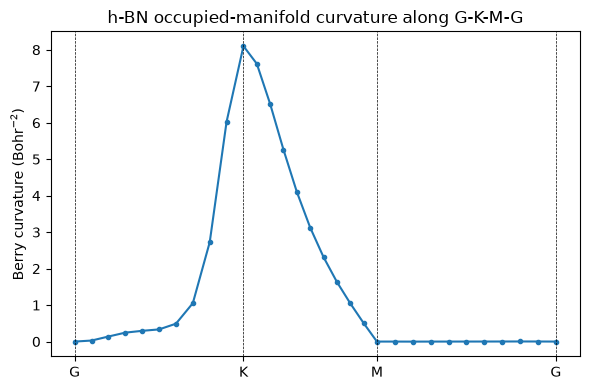

In [6]:
def segment(k_start, k_end, n):
    k_start, k_end = np.array(k_start), np.array(k_end)
    return [tuple(k_start + (k_end - k_start) * t) for t in np.linspace(0, 1, n)]

path_kpoints = (
    segment((0.0, 0.0, 0.0), (1 / 3, 1 / 3, 0.0), 11)
    + segment((1 / 3, 1 / 3, 0.0), (0.5, 0.0, 0.0), 11)[1:]
    + segment((0.5, 0.0, 0.0), (0.0, 0.0, 0.0), 11)[1:]
)
path_result = hbn_calc.get_berry_curvature_path(
    path_kpoints, ist0, ist1, directions=(1, 2), dk=0.01, label="berry_path_GKM"
)
path_curvature = [p["curvature"] for p in path_result]
path_distance = np.cumsum([0.0] + [np.linalg.norm(np.array(b) - np.array(a))
                                    for a, b in zip(path_kpoints[:-1], path_kpoints[1:])])

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(path_distance, path_curvature, marker="o", ms=3)
for label, x in zip(["G", "K", "M", "G"], [path_distance[0], path_distance[10], path_distance[20], path_distance[-1]]):
    ax.axvline(x, color="k", lw=0.5, ls="--")
ax.set_xticks([path_distance[0], path_distance[10], path_distance[20], path_distance[-1]])
ax.set_xticklabels(["G", "K", "M", "G"])
ax.set_ylabel("Berry curvature (Bohr$^{-2}$)")
ax.set_title("h-BN occupied-manifold curvature along G-K-M-G")
fig.tight_layout()

Curvature is sharply peaked right at K and essentially flat (zero) elsewhere along
this path -- consistent with the picture above of curvature concentrated at the
inequivalent K/K' valleys.

## Next

`06_eigenstate_session.ipynb` -- the interactive eigenstate/overlap query session
(task 9002), the third and most recent elkpy Fortran extension.